In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
import heapq
from sklearn.feature_selection import SelectKBest, SelectPercentile, mutual_info_classif, chi2
from matplotlib import pyplot as plt

def read_data(data_path):
    data = pd.read_csv(data_path, header=None)
    X = np.array(data.iloc[1:].values.T[1:], dtype=float)
    y = list(data.iloc[0][1:])
    name_genes = data[0].values[1:]
    return X, y, name_genes
X, y, name_genes = read_data('GSE82009_max.csv')
print('number of genes after preprocessing is ', len(name_genes))

print(len(y))
print(len(X[0]))

number of genes after preprocessing is  9141
50
9141


In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
scaler = MinMaxScaler()
scaler = scaler.fit(X)
result = scaler.transform(X)
print(pd.DataFrame(result))

        0         1         2         3         4         5         6     \
0   0.245416  0.197226  1.000000  0.542364  1.000000  1.000000  0.350544   
1   0.686353  0.408283  0.407137  0.710773  0.601062  0.720497  0.567301   
2   0.412557  0.467126  0.583125  0.746133  0.852686  0.646091  0.782530   
3   0.346632  1.000000  0.000000  0.822800  0.332658  0.602172  0.248886   
4   0.785381  0.270714  0.552028  0.549997  0.604706  0.600118  0.215788   
5   0.579404  0.700079  0.699993  0.838694  0.498205  0.490624  0.694731   
6   0.399574  0.256748  0.501009  0.665531  0.502282  0.729922  0.339842   
7   0.970326  0.523234  0.780424  0.698718  0.727849  0.554038  0.355760   
8   0.300786  0.230360  0.605391  0.696068  0.608444  0.592420  0.503374   
9   0.493211  0.776201  0.418135  1.000000  0.229033  0.090786  0.228737   
10  0.523141  0.167976  0.751187  0.359158  0.604830  0.787732  1.000000   
11  0.485446  0.200161  0.535005  0.677348  0.993867  0.538373  0.462464   
12  0.743541

In [3]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import SelectFromModel

clf = ExtraTreesClassifier()
clf = clf.fit(X, y)
clf.feature_importances_
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X)
X_new.shape

(50, 864)

In [4]:
import numpy as np
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier as RFC
from matplotlib import pyplot as plt
from sklearn.model_selection import StratifiedKFold


class NSGA2():
    def __init__(self, all_genes, pop_size, max_generations, max_Ngen, features, labels):
        self.all_genes = all_genes
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_Ngen = max_Ngen
        self.features = features
        self.labels = labels

    def fast_non_dominated_sort(self, all_values):
        values1, values2 = all_values[0], all_values[1]
#         print(len(values1), len(values2))
        S=[[] for i in range(0,len(values1))]
        front = [[]]
        n=[0 for i in range(0,len(values1))]
        rank = [0 for i in range(0, len(values1))]

        for p in range(0,len(values1)):
            S[p]=[]
            n[p]=0
            for q in range(0, len(values1)):
                if (values1[p] > values1[q] and values2[p] > values2[q]) or\
                        (values1[p] >= values1[q] and values2[p] > values2[q]) or\
                        (values1[p] > values1[q] and values2[p] >= values2[q]):
                    if q not in S[p]:
                        S[p].append(q)
                elif (values1[q] > values1[p] and values2[q] > values2[p]) or\
                        (values1[q] >= values1[p] and values2[q] > values2[p]) or\
                        (values1[q] > values1[p] and values2[q] >= values2[p]):
                    n[p] = n[p] + 1
            if n[p]==0:
                rank[p] = 0
                if p not in front[0]:
                    front[0].append(p)

        i = 0
        while(front[i] != []):
            Q=[]
            for p in front[i]:
                for q in S[p]:
                    n[q] =n[q] - 1
                    if( n[q]==0):
                        rank[q]=i+1
                        if q not in Q:
                            Q.append(q)
            i = i+1
            front.append(Q)

        del front[len(front)-1]
#         print(n)
        return front


#     def fast_non_dominated_sort(self, all_values):
#         N = len(all_values[0])
#         n = [0] * N
#         S = [[] for _ in range(N)]
#         pareto_rank = [0] * N
#         pareto_sorted = [[]]
#         for i in range(N):
#             for j in range(i+1, N):
#                 if (all_values[:, i] > all_values[:, j]).all() or \
#                    ((all_values[:, i] >= all_values[:, j]).all() and (all_values[:, i] != all_values[:, j]).any()):
#                     S[i].append(j)
#                     n[j] += 1
#                 elif (all_values[:, j] > all_values[:, i]).all() or \
#                      ((all_values[:, j] >= all_values[:, i]).all() and (all_values[:, j] != all_values[:, i]).any()):
#                     S[j].append(i)
#                     n[i] += 1
#             if n[i] == 0:
#                 pareto_sorted[0].append(i)
#         cur_rank = 0
#         while True:
#             sub_pareto = []
#             for i in range(N):
#                 if pareto_rank[i] == cur_rank:
#                     for j in S[i]:
#                         n[j] -= 1
#                         if n[j] == 0:
#                             pareto_rank[j] = cur_rank + 1
#                             sub_pareto.append(j)
#             if len(sub_pareto) > 0:
#                 pareto_sorted.append(sub_pareto)
#             else:
#                 break
#             cur_rank += 1
#         print(n)
# #         print(S)
#         return pareto_sorted

    def crowding_distance_sort(self, all_values, sub_pareto):
        N = len(sub_pareto)
        cd = [0] * N
        for values in all_values:
            sub_values = values[sub_pareto]
            max_value = np.max(sub_values)
            min_value = np.min(sub_values)
            sub_values_argsorted = np.argsort(sub_values)
            for i in range(1, N-1):
                cd[sub_values_argsorted[i]] += (sub_values[sub_values_argsorted[i+1]] - sub_values[sub_values_argsorted[i-1]]) / (max_value - min_value)
#         print(np.array(np.argsort(cd), dtype=int))
        return np.array(sub_pareto)[np.array(np.argsort(cd), dtype=int)]


    # def crossover(solution_a, solution_b):
    #     if np.random.rand(1) > 0.5:
    #         return mutation((solution_a + solution_b) / 2)
    #     else:
    #         return mutation((solution_a - solution_b) / 2)

    # def mutation(parent):
    #     M = 100
    #     u = np.random.rand(M)
    #     delta = ((2 * u) ** (1 / (1 + eta)) - 1) * (u < 0.5) + (1 - (2 * (1 - u)) ** (1 / (1 + eta))) * (u > 0.5)
    #     child = parent + delta
    #     child[child > x_max] = x_max[child > x_max]
    #     child[child < x_min] = x_min[child < x_min]
    #
    # def crossover():
    #     N = 10
    #     M = 100
    #     parent_1, parent_2 = np.random.choice(N, 2, replace=False)
    #     if np.random.rand() < 0.5:
    #         u = np.random.rand(M)
    #         gamma = (2 * u) ** (1 / (1 + eta)) * (u < 0.5) + (1 / (2 * (1 - u))) ** (1 / (1 + eta)) * (u > 0.5)
    #         child_1 = 0.5 * ((1 + gamma) * parent_1 + (1 - gamma) * parent_2)
    #         child_2 = 0.5 * ((1 - gamma) * parent_1 + (1 + gamma) * parent_2)
    #         child_1[child_1 > x_max] = x_max[child_1 > x_max]
    #         child_1[child_1 < x_min] = x_min[child_1 < x_min]
    #         child_2[child_2 > x_max] = x_max[child_2 > x_max]
    #         child_2[child_2 < x_min] = x_min[child_2 < x_min]


    def mutation(self, solution):
        list_solution = list(solution)[:]
        if len(list_solution) < self.max_Ngen and len(list_solution) > 1:
            if np.random.rand() < 1/3:
                list_solution.pop(np.random.randint(len(list_solution)))
            elif np.random.rand() < 2/3:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
            else:
                list_solution.append(np.random.randint(len(self.all_genes)))
        elif len(solution) < self.max_Ngen:
            if np.random.rand() < 0.5:
                list_solution.append(np.random.randint(len(self.all_genes)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
        else:
            if np.random.rand() < 0.5:
                list_solution.pop(np.random.randint(len(list_solution)))
            else:
                list_solution[np.random.randint(len(list_solution))] = np.random.randint(len(self.all_genes))
#         print(list_solution)
        return np.array(list_solution)

    # def tournament_selection(candidates):
    #     double_N = len(candidates)
    #     k = double_N // 2

    def elitism(self, all_values, pareto_sorted):
        new_parents = []
        for sub_pareto in pareto_sorted:
#             print(sub_pareto)
            if len(sub_pareto) + len(new_parents) <= self.pop_size:
                new_parents.extend(sub_pareto)
            else:
                new_parents.extend(self.crowding_distance_sort(all_values, sub_pareto)[:self.pop_size-len(new_parents)])
        return new_parents

    def train(self, train_features, train_labels):
        model = svm.SVC()

#         print(train_features.shape)
        model.fit(train_features.reshape(train_features.shape[0], -1), train_labels.reshape(-1, 1))
        return model

    def test(self, test_features, test_labels, model):
        return model.score(test_features.reshape(test_features.shape[0], -1), test_labels.reshape(-1, 1))

    def function1(self, solution):
#         print(solution.shape)
        features = self.features[:, solution]
    
        accs = []
        cv = StratifiedKFold(n_splits=10, shuffle=False)
        for train_idx, test_idx in cv.split(features, self.labels):
            model = self.train(features[train_idx], self.labels[train_idx])
            accs.append(self.test(features[test_idx], self.labels[test_idx], model))
        return np.mean(accs)

    def function2(self, solution):
#         print(solution)
        num_genes = len(solution)
        return (len(self.all_genes) - num_genes) / len(self.all_genes)

    def execute(self):
        # 随机生成初始种群
        solutions = [np.random.choice(list(range(len(self.all_genes))), 1 + int(np.random.rand() * self.max_Ngen), False)\
                    for _ in range(self.pop_size)]
        solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
#         print(solutions)
        for num_generation in range(self.max_generations):
            # 自适应度计算
#             print(len(solutions))
            solutions = [np.array([solution]) if isinstance(solution, int) else solution for solution in solutions]
            f1_values = [self.function1(solutions[i]) for i in range(0, self.pop_size)]
            f2_values = [self.function2(solutions[i]) for i in range(0, self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            values = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            probabilities = 0.1 + 0.9 * values / np.sum(values)
            probabilities = probabilities / np.sum(probabilities)
            # pareto等级
            non_dominated_sorted_solutions = self.fast_non_dominated_sort(all_values)
            
            accs = [nsga2.function1(solution) for solution in solutions]
            nums = [len(solution) for solution in solutions]
            scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
            print(f'the best one of generation {num_generation} is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
            

            new_solutions = solutions[:]  # P+Q
            for i in range(self.pop_size):
                new_solution = self.mutation(solutions[np.random.choice(list(range(len(solutions))), p=probabilities)])
#                 print(new_solution)
                new_solutions.append(new_solution)
            # 计算 P+Q种群的适应度
            f1_values = [self.function1(new_solutions[i]) for i in range(2 * self.pop_size)]
            f2_values = [self.function2(new_solutions[i]) for i in range(2 * self.pop_size)]
            all_values = np.array([f1_values, f2_values])
            # 非支配排序
            non_dominated_sorted_new_solutions = self.fast_non_dominated_sort(all_values)
#             print(non_dominated_sorted_new_solutions)
            # 得到下一代种群
#             print(len(new_solutions))
#             for i in self.elitism(all_values, non_dominated_sorted_new_solutions):
#                 print(i)
            solutions = [new_solutions[i] for i in self.elitism(all_values, non_dominated_sorted_new_solutions)]  # index
        return solutions





In [5]:
df = pd.DataFrame(X_new)
X4= df.T
index_list = X4.index.tolist()
final_genes = name_genes[index_list]
print(len(final_genes))

864


the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 11 is: accuracy is  0.9400000000000001 , num of genes is  5
the best on

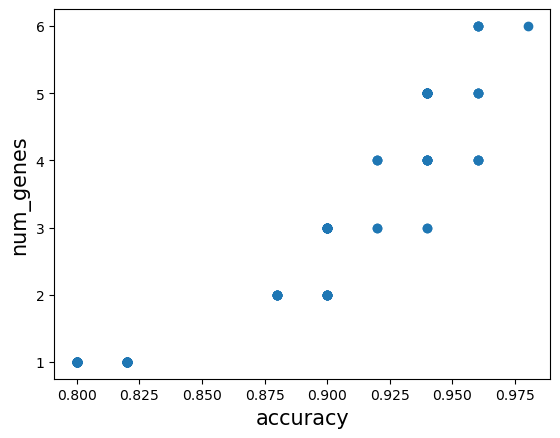

the best one is: accuracy is  0.9800000000000001 , num of genes is  6
selected genes are:  ['BCL2L2-PABPN1 ' 'ACVRL1' 'ALPI' 'ADAMTSL3' 'BAP1' 'AARS']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of 

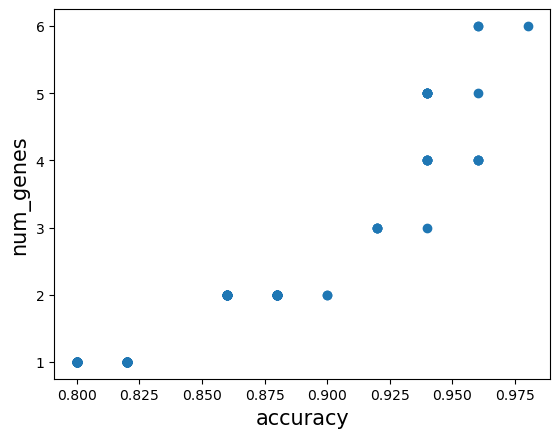

the best one is: accuracy is  0.9800000000000001 , num of genes is  6
selected genes are:  ['ABHD3' 'APOOL' 'ANKLE2' 'ARSF' 'AK6 ' 'ATP2B2']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is

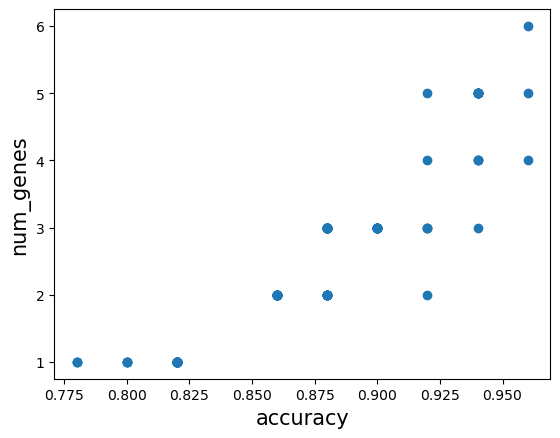

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['AGRP' 'ABL2' 'ARVCF' 'AURKC']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  2
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 10 is: accuracy is 

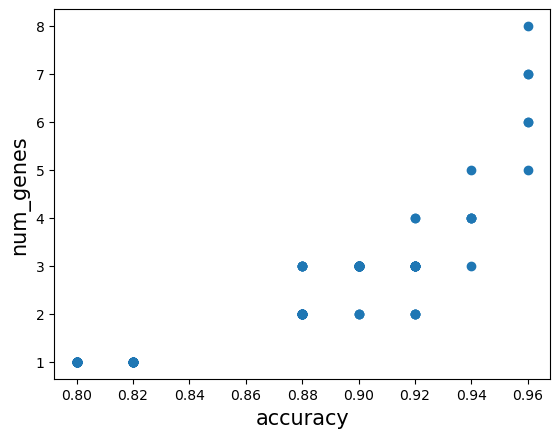

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['ADAM28' 'ARPC2' 'BMI1 ' 'AMOT' 'ADSS']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  3
the best 

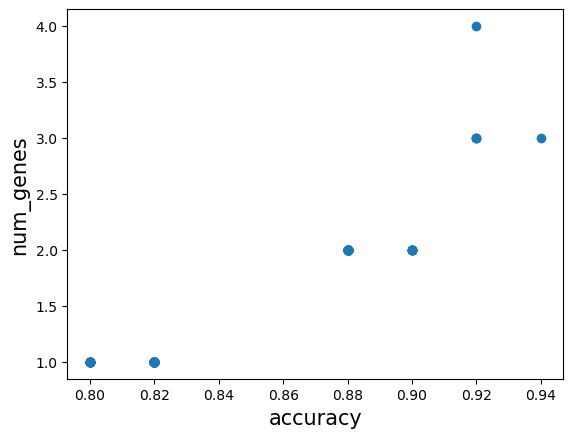

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['APOE' 'BMP5' 'ARL2-SNX15 ']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 10 is: accuracy is  0.940000000000000

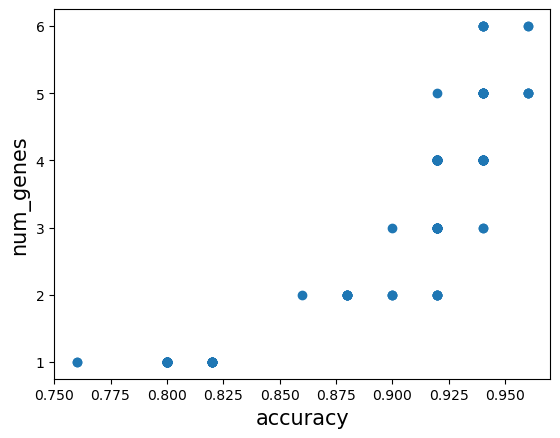

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['ALOX12' 'AUTS2' 'ACAA1' 'ALPI' 'ABCA5']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.919999999999999

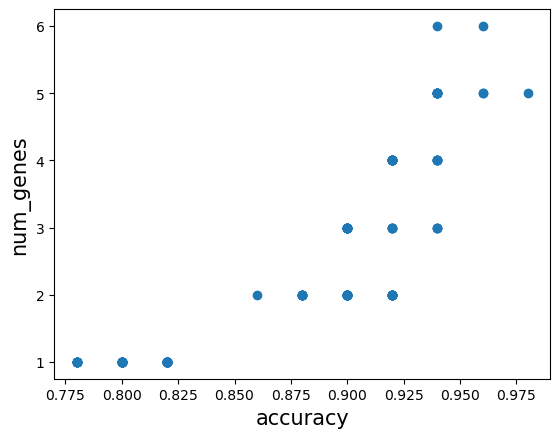

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['BCL2L2-PABPN1 ' 'ANGEL2' 'ALG11 ' 'BAMBI' 'ARF1 ']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generat

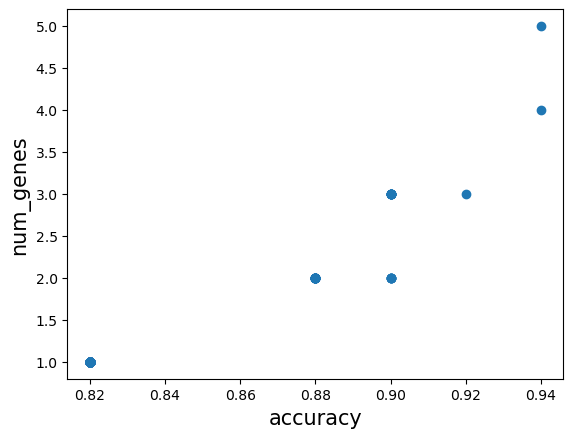

the best one is: accuracy is  0.9400000000000001 , num of genes is  4
selected genes are:  ['ASCC2' 'ALPI' 'ATP6V0A1' 'ACVR1']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  3
the best one 

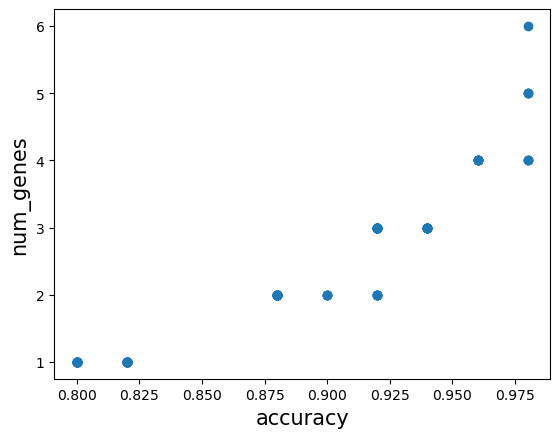

the best one is: accuracy is  0.9800000000000001 , num of genes is  4
selected genes are:  ['AOAH' 'BCL2A1' 'ADRA2A' 'APOE']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of 

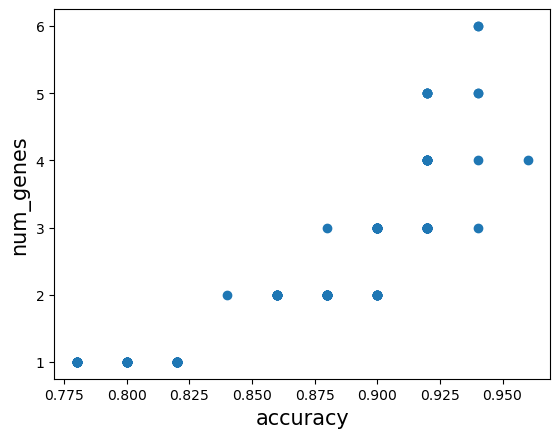

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ADRA2A' 'BCL2L2-PABPN1 ' 'ANKHD1 ' 'AP3D1']
the best one of generation 0 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of g

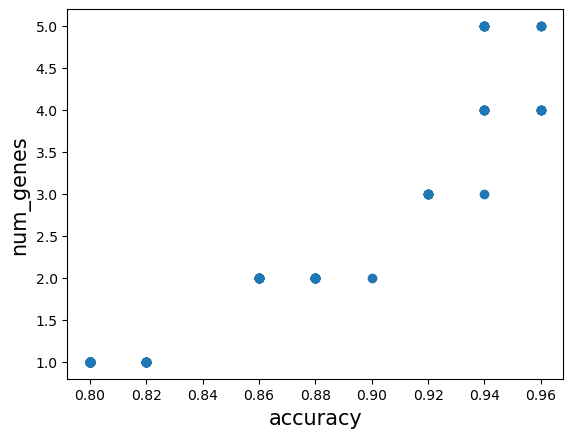

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ATP2B3' 'AMACR ' 'B2M' 'BAMBI']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  6
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.96 , num of genes is  7
the best one of generation 10 is: accuracy is  0.96 , num

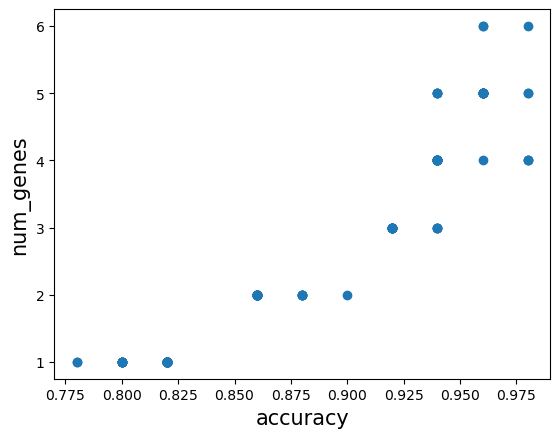

the best one is: accuracy is  0.9800000000000001 , num of genes is  4
selected genes are:  ['APOE' 'ADRA2A' 'ANPEP' 'ABCC3']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 4 is: accuracy is  0.96 , num of genes is  7
the best one of generation 5 is: accuracy is  0.96 , num of genes is  7
the best one of generation 6 is: accuracy is  0.96 , num of genes is  7
the best one of generation 7 is: accuracy is  0.96 , num of genes is  6
the best one of generation 8 is: accuracy is  0.96 , num of genes is  6
the best one of generation 9 is: accuracy is  0.96 , num of genes is  6
the best one of generation 10 is: accuracy is  0.96 , num of genes is  6
the best one of generation

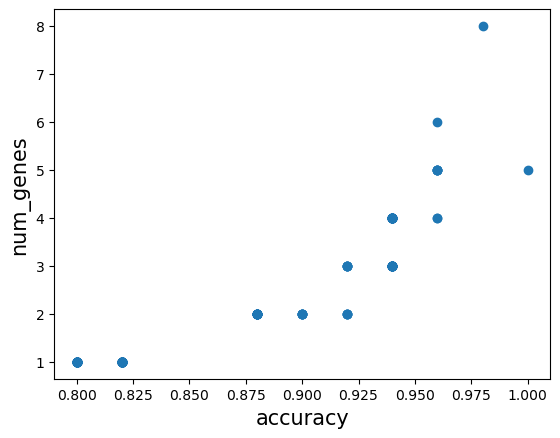

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['APOE' 'ARL6IP1' 'AREL1' 'AP3B2' 'ALG11 ']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  8
the bes

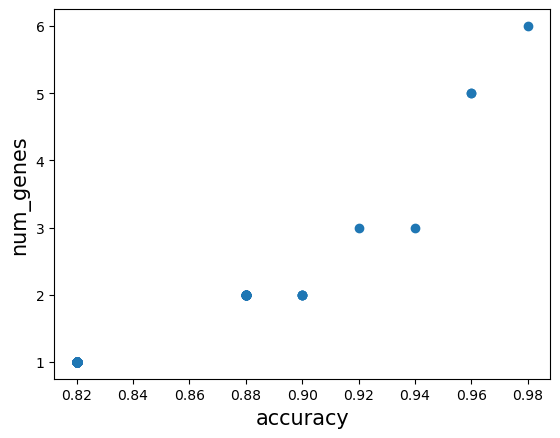

the best one is: accuracy is  0.9800000000000001 , num of genes is  6
selected genes are:  ['BDH1' 'ADRA2A' 'AP2B1' 'BMP3' 'ALOX12' 'ACAA1']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.86 , num of genes is  6
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  8
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 1

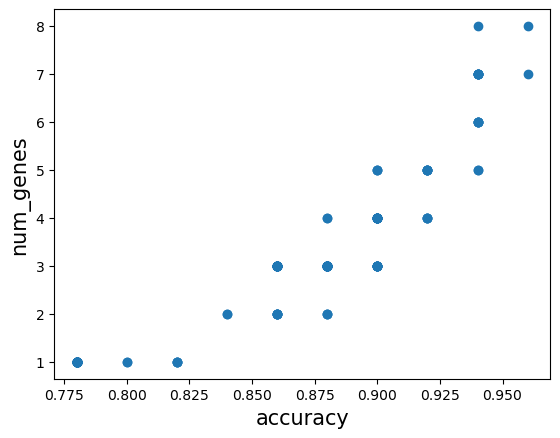

the best one is: accuracy is  0.96 , num of genes is  7
selected genes are:  ['APOOL' 'ADSL' 'BCL10' 'AFG3L2' 'ACIN1' 'ARL6IP1' 'ARFGAP2']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  9
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of 

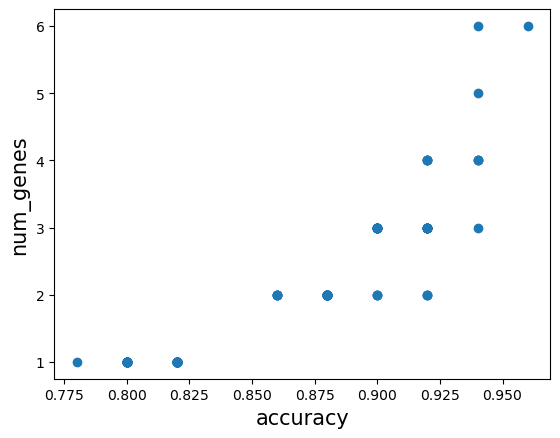

the best one is: accuracy is  0.96 , num of genes is  6
selected genes are:  ['B4GALT1' 'ARIH2' 'ABCA4' 'APOE' 'AGPS' 'ADAMTS2']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 9 is: accuracy is  0.96 , num of genes is  8
the best one of generatio

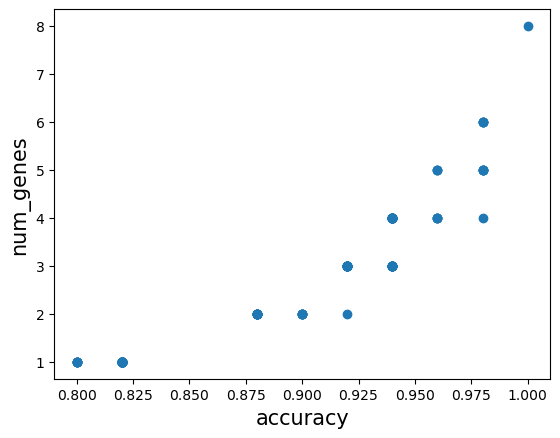

the best one is: accuracy is  1.0 , num of genes is  8
selected genes are:  ['ADRA2A' 'ACAA1' 'APC2' 'ASXL1' 'APOE' 'ARMCX4' 'AKAP12' 'ASXL1']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  6
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  6
the best one of generation 2 is: accuracy is  0.8600000000000001 , num of genes is  6
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation

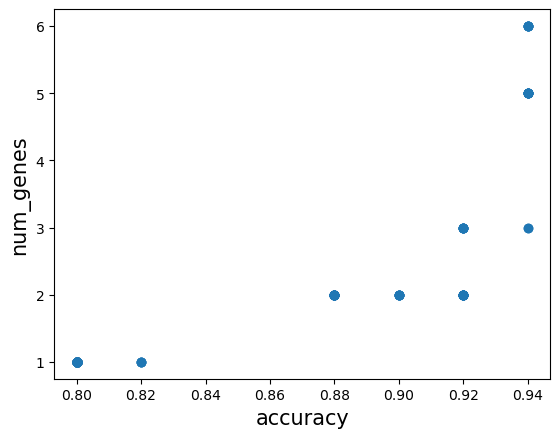

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['ALOX12' 'ACVR1' 'B4GALT3']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one 

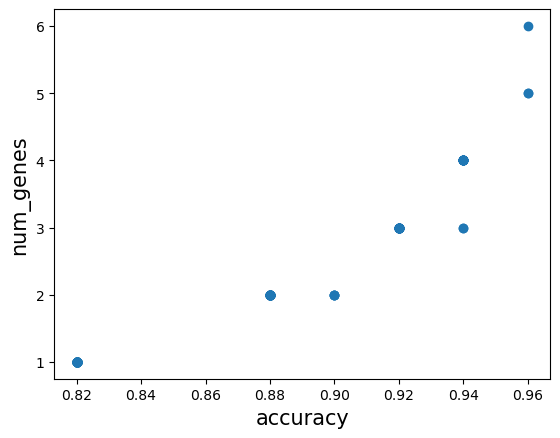

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['BAZ2B' 'ATP9A' 'APOE' 'BMP5' 'AGGF1']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is

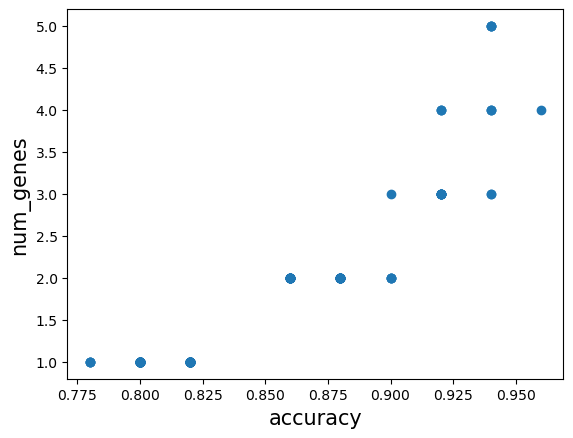

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ALOX12' 'ARHGAP22' 'ACAA1' 'ANXA8 ']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 2 is: accuracy is  0.9400000000000001 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9400000000000001 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9400000000000001 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  6
the best one of generation 6 is: accuracy is  0.96 , num of genes is  8
the best one of generation 7 is: accuracy is  0.96 , num of genes is  7
the best one of generation 8 is: accuracy is  0.96 , num of genes is  7
the best one of generation 9 is: accuracy is  0.96 , num of genes is  7
the best one of generation 10 is: accuracy is  0.96 , num of genes is  7
the best one of genera

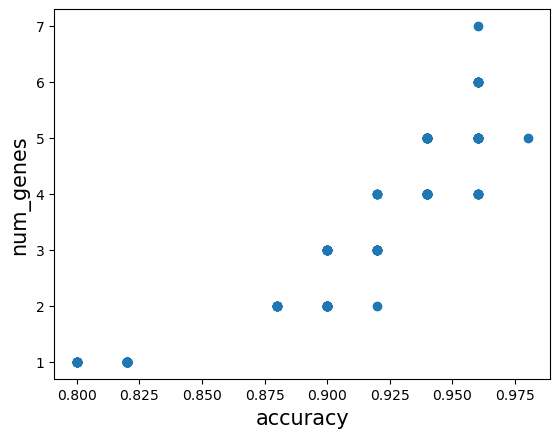

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['BEST1' 'BMP2K' 'ARAF' 'ALOX12' 'ATOX1']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  8
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.96 , num of genes is  5
the best one of generation 7 is: accuracy is  0.96 , num of genes is  5
the best one of generation 8 is: accuracy is  0.96 , num of genes is  5
the best one of generation 9 is: accuracy is  0.96 , num of genes is  5
the best one of generation 10 is: accuracy is  0.96 , num of genes is  5
the best one of generation 11 is: accuracy is  0.

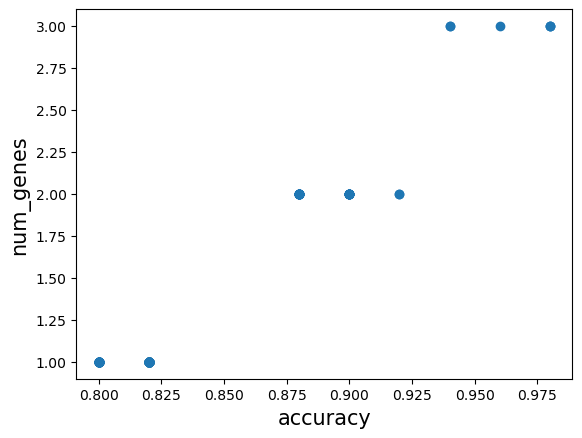

the best one is: accuracy is  0.9800000000000001 , num of genes is  3
selected genes are:  ['BCL2L2-PABPN1 ' 'ASXL1' 'ALDH5A1']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 2 is: accuracy is  0.9 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9 , num of genes is  2
the best one of generation 9 is: accuracy is  0.9 , num of genes is  2
the best one of generation 10 is: accuracy is  0.9 , num of genes is  2
the best one of generation 11 is: accuracy is  0.9 , num 

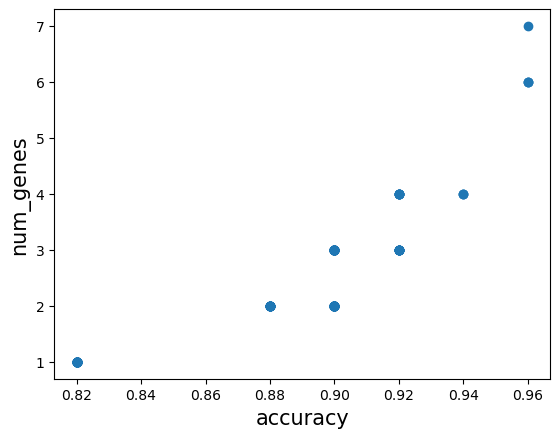

the best one is: accuracy is  0.96 , num of genes is  6
selected genes are:  ['AASDHPPT' 'ARMCX2' 'BCL2L2-PABPN1 ' 'ACTN3' 'ALOX15' 'ANXA4']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 10 is: accuracy i

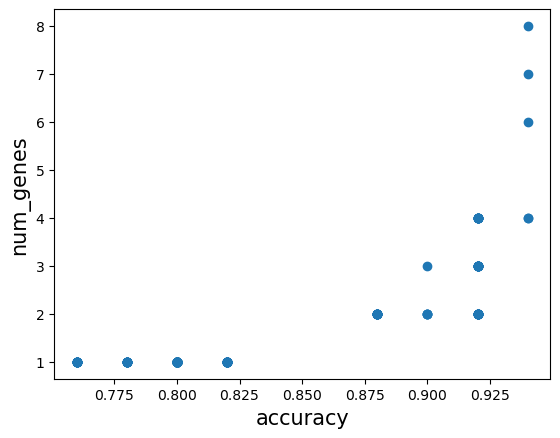

the best one is: accuracy is  0.9400000000000001 , num of genes is  4
selected genes are:  ['ALOX12' 'ACADSB' 'B3GAT3' 'ARNT']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 11 i

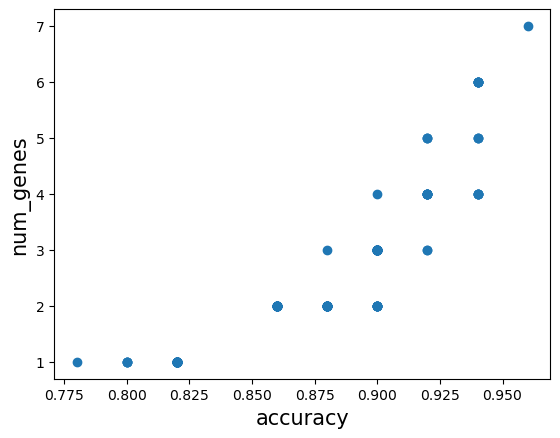

the best one is: accuracy is  0.96 , num of genes is  7
selected genes are:  ['AARS' 'ACTL8' 'ABCC3' 'ARHGDIB' 'B2M' 'AGTR2' 'ATP8B3']


In [9]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=10,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.86 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 11 is: accuracy is  0.96 , num of genes is  10
the best one of generation 12 is: accu

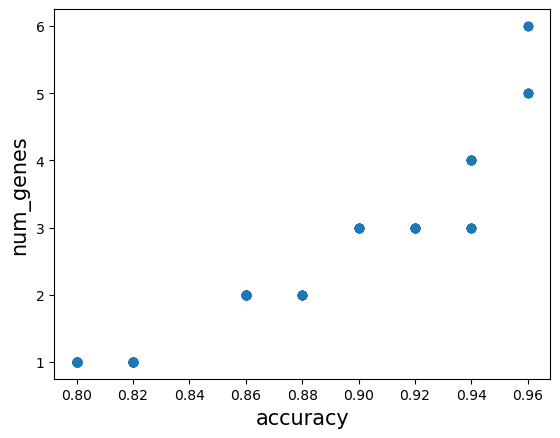

the best one is: accuracy is  0.9600000000000002 , num of genes is  5
selected genes are:  ['ALOX12' 'ANP32B' 'BMI1 ' 'ACAA1' 'ASXL1']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  7
the best one of generation 1 is: accuracy is  0.9 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 5 is: accuracy is  0.96 , num of genes is  15
the best one of generation 6 is: accuracy is  0.96 , num of genes is  10
the best one of generation 7 is: accuracy is  0.96 , num of genes is  10
the best one of generation 8 is: accuracy is  0.96 , num of genes is  10
the best one of generation 9 is: accuracy is  0.96 , num of genes is  10
the best one of generation 10 is: accuracy is  0.96 , num of genes is  10
the best one of generation 11 is: acc

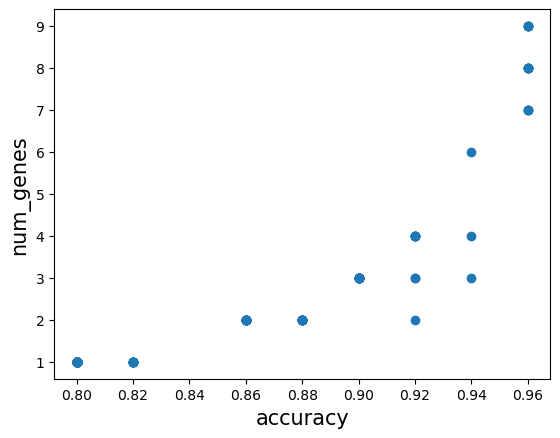

the best one is: accuracy is  0.96 , num of genes is  7
selected genes are:  ['AGFG1' 'AP3S1' 'ARID4B' 'AKR1D1' 'ALOX12' 'ABHD3' 'AURKC']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9 , num of genes is  14
the best one of generation 3 is: accuracy is  0.9 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  6
the best one of generation 9 is: accuracy is  0.96 , num of genes is  6
the best one of generation 10 is: accuracy is  0.96 , num of genes is  6
the best one of generation 11

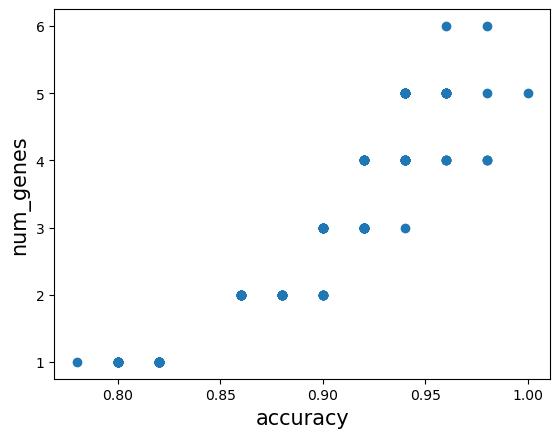

the best one is: accuracy is  1.0 , num of genes is  5
selected genes are:  ['ARHGAP1' 'ADRA2C' 'AMMECR1' 'ATRIP ' 'APOE']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  8
the best one of generation 8 is: accuracy is  0.96 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9800000000000001 , num of genes is  11
the best one of generation 10 is: accuracy is  0.98000000

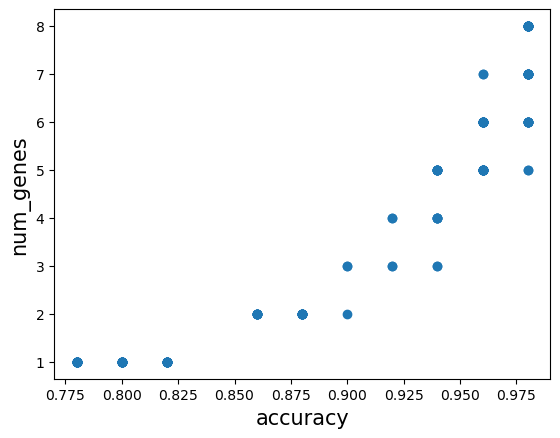

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['BCL2L2-PABPN1 ' 'ANKRD46' 'APOD' 'AKR1D1' 'ANXA5']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  5
the best o

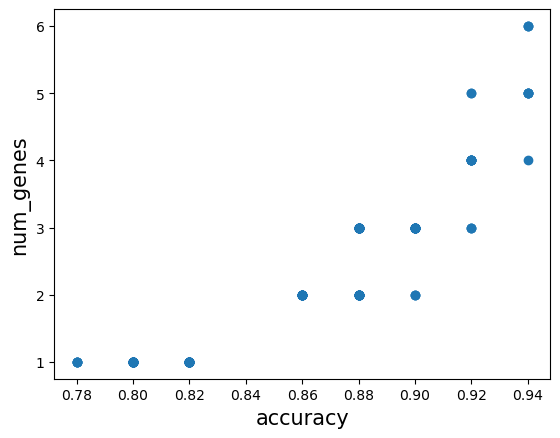

the best one is: accuracy is  0.9400000000000001 , num of genes is  4
selected genes are:  ['ALOX12' 'ABCA4' 'AMOTL2' 'AMHR2']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  13
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  12
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  11
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  11
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 9 is: accuracy is  0.96 , num of genes is  11
the best one of g

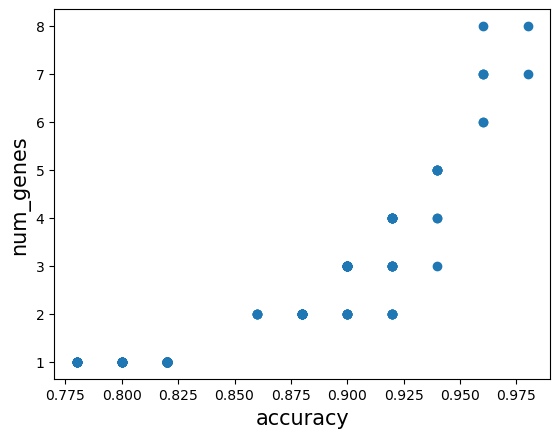

the best one is: accuracy is  0.9800000000000001 , num of genes is  7
selected genes are:  ['BIRC5' 'ARNT' 'AREL1' 'AURKC' 'BLVRB' 'BMP2K' 'AQP3']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  11
the best one of generation 1 is: accuracy is  0.9 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9 , num of genes is  11
the best one of generation 3 is: accuracy is  0.9 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  10
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of g

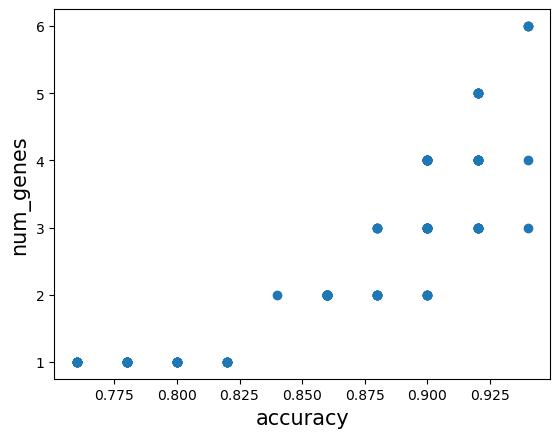

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['B2M' 'ANKRD40' 'ACTA2']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  12
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  12
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  11
the best one of generation 3 is: accuracy is  0.9 , num of genes is  11
the best one of generation 4 is: accuracy is  0.9 , num of genes is  10
the best one of generation 5 is: accuracy is  0.9 , num of genes is  10
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  7
the b

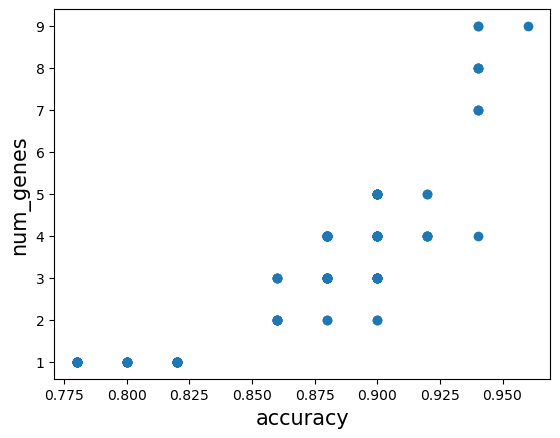

the best one is: accuracy is  0.96 , num of genes is  9
selected genes are:  ['ABHD3' 'BAK1' 'ATP4A' 'BDH1' 'ABCC10' 'APPBP2' 'AVPR1A' 'ACADS' 'ARSA']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 8 is: accuracy is  0.96 , num of genes is  7
the best one of generation 9 is: accuracy is  0.96 , num of genes is  7
the best one of generation 10 is: accuracy is  0.96 , num of g

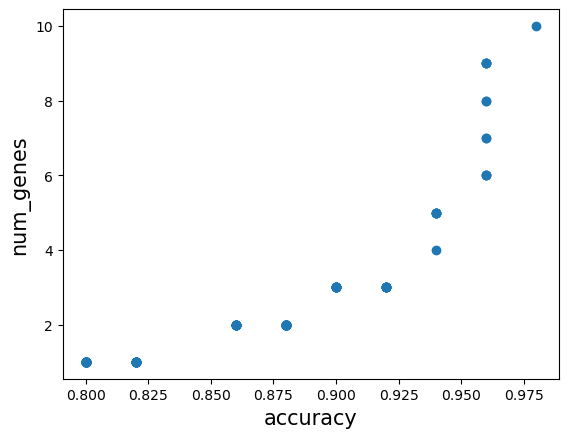

the best one is: accuracy is  0.9800000000000001 , num of genes is  10
selected genes are:  ['ASCC2' 'AGRN' 'ACAA2' 'ALDH3A1' 'ACTL6B' 'ALDH2' 'ABL1' 'AP3B2' 'BATF'
 'ATP2C2']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9400000000000001 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9400000000000001 , num of genes is  12
the best one of generation 3 is: accuracy is  0.9400000000000001 , num of genes is  12
the best one of generation 4 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 5 is: accuracy is  0.96 , num of genes is  7
the best one of generation 6 is: accuracy is  0.96 , num of genes is  7
the best one of generation 7 is: accuracy is  0.96 , num of genes is  7
the best one of generation 8 is: accuracy is  0.96 , num of genes is  7
the best one of generation 9 is: accuracy is  0.96 , num of genes is  6
the best one of generation 10 i

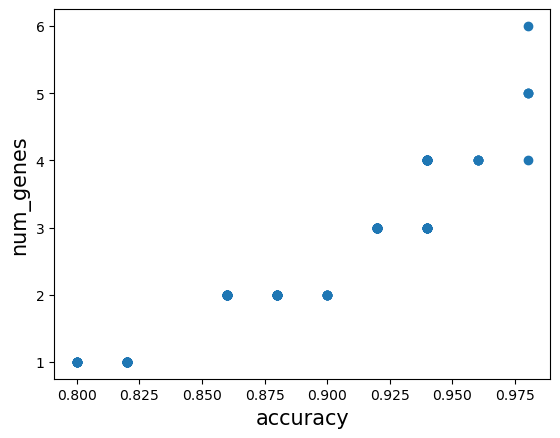

the best one is: accuracy is  0.9800000000000001 , num of genes is  4
selected genes are:  ['B2M' 'ALOX12' 'AREL1' 'ALPI']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 1

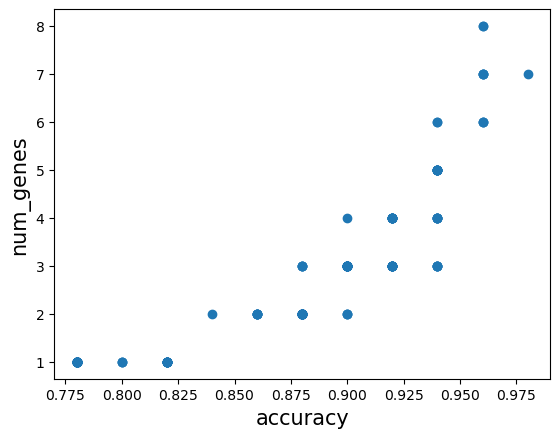

the best one is: accuracy is  0.9800000000000001 , num of genes is  7
selected genes are:  ['ANKMY2' 'APBB2' 'ANO3' 'ANXA5' 'AMOT' 'ACP1' 'ATOX1']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  8
the best one of generation 1 is: accuracy is  0.9 , num of genes is  8
the best one of generation 2 is: accuracy is  0.9 , num of genes is  8
the best one of generation 3 is: accuracy is  0.9 , num of genes is  8
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  9
the best one of generation 10 is: accu

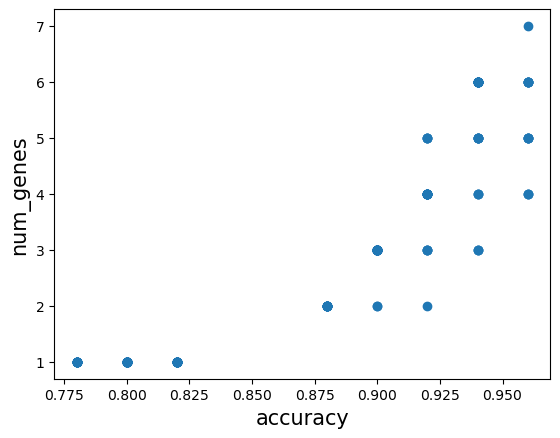

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ADRA2A' 'BCL10' 'ACKR1' 'AGRN']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  13
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  11
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  4


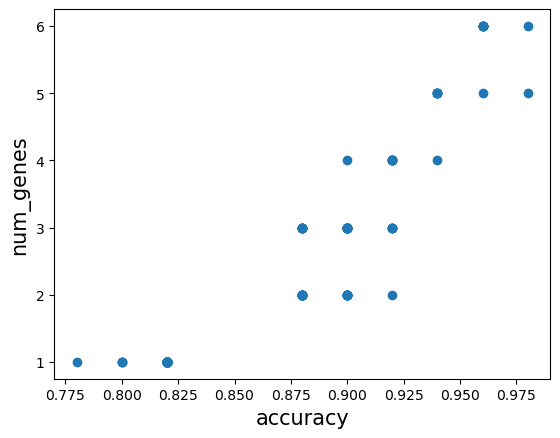

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['ARSF' 'ACADL' 'AHCY' 'ATF3' 'ART4']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  15
the best one of generation 1 is: accuracy is  0.9 , num of genes is  15
the best one of generation 2 is: accuracy is  0.9 , num of genes is  15
the best one of generation 3 is: accuracy is  0.9 , num of genes is  14
the best one of generation 4 is: accuracy is  0.9 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of ge

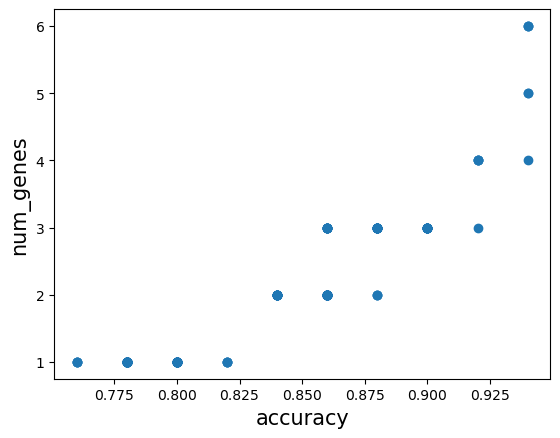

the best one is: accuracy is  0.9400000000000001 , num of genes is  4
selected genes are:  ['B3GAT2' 'ARHGAP22' 'ACVR1' 'ATF5']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9199999999999999 , nu

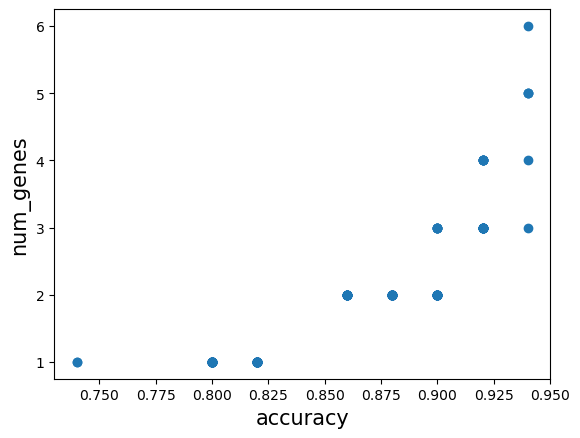

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['APOE' 'AL928768.3 ' 'BDH1']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  9
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  14
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  7
the best one of ge

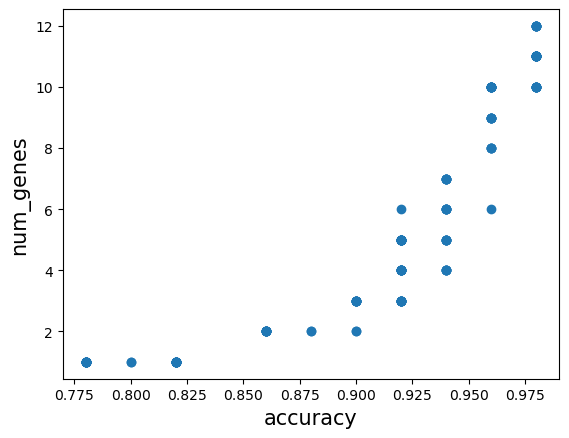

the best one is: accuracy is  0.9800000000000001 , num of genes is  10
selected genes are:  ['ACTR1A' 'AATF' 'ART4' 'B2M' 'ARHGEF6' 'AURKC' 'API5' 'ACOX2' 'ACTR3'
 'BGLAP ']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  11
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  11
the best one of generation 3 is: accuracy is  0.96 , num of genes is  11
the best one of generation 4 is: accuracy is  0.96 , num of genes is  10
the best one of generation 5 is: accuracy is  0.96 , num of genes is  10
the best one of generation 6 is: accuracy is  0.96 , num of genes is  10
the best one of generation 7 is: accuracy is  0.96 , num of genes is  10
the best one of generation 8 is: accuracy is  0.96 , num of genes is  9
the best one of generation 9 is: accuracy is  0.96 , num of genes is  9
the best one of generation 10 is: accuracy is  0.9800000

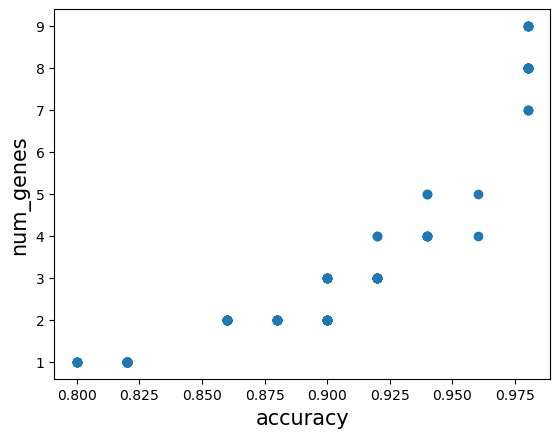

the best one is: accuracy is  0.9800000000000001 , num of genes is  7
selected genes are:  ['ASCL2' 'ATP6AP1' 'ATM' 'ARSF' 'ALDH3A1' 'ATP5F1' 'AMOT']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  6
the best one of generation 1 is: accuracy is  0.9 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  12
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  12
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  14
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generatio

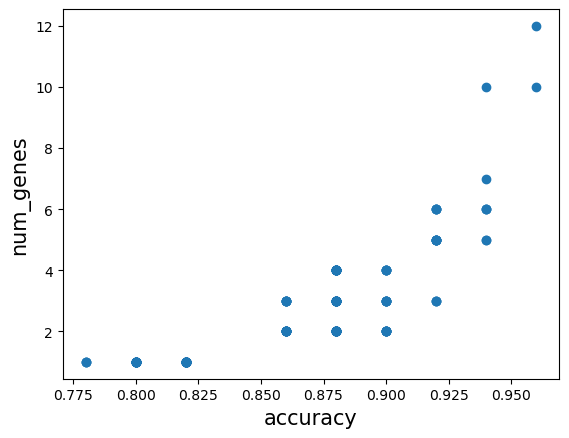

the best one is: accuracy is  0.96 , num of genes is  10
selected genes are:  ['AMOT' 'AKAP9' 'APC' 'ABCD4' 'ARFGEF2' 'BDH1' 'ADAM3A' 'BMP3' 'ABI2'
 'ACO2']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  10
the best one of generation 1 is: accuracy is  0.9 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  7


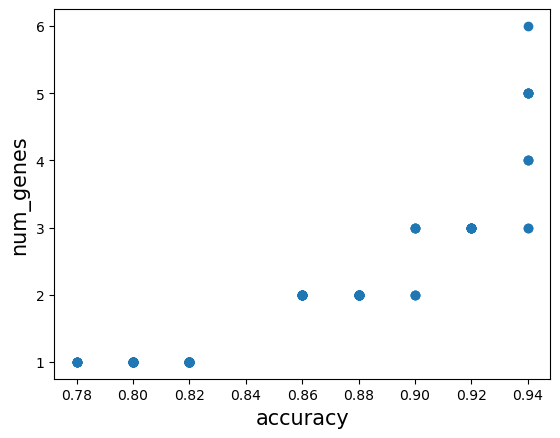

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['BDH1' 'AL928768.3 ' 'APOE']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9 , num of genes is  10
the best one of generation 2 is: accuracy is  0.9 , num of genes is  7
the best one of generation 3 is: accuracy is  0.9 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9 , num of genes is  7
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  7
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  8
the b

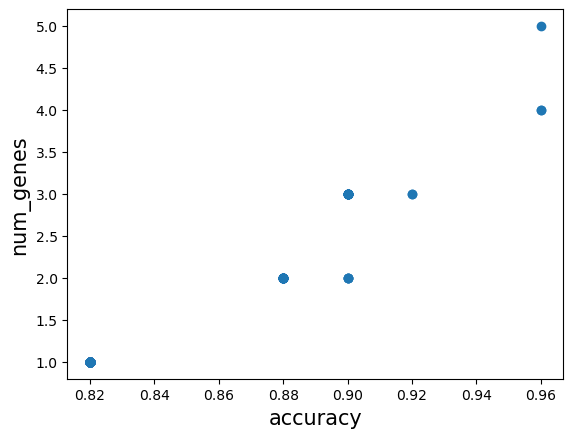

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ASXL1' 'ANP32B' 'ACBD3' 'BDH1']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  13
the best one of generation 1 is: accuracy is  0.9 , num of genes is  13
the best one of generation 2 is: accuracy is  0.9 , num of genes is  13
the best one of generation 3 is: accuracy is  0.9 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  8
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is

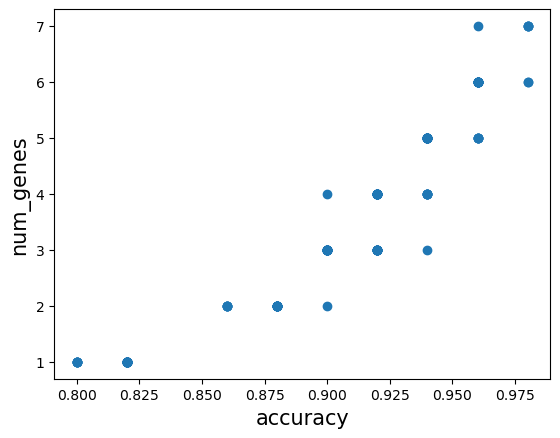

the best one is: accuracy is  0.9800000000000001 , num of genes is  6
selected genes are:  ['ARSF' 'AL109706' 'ADSS' 'ACTB' 'APEX1' 'ADRA2A']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  12
the best one of generation 1 is: accuracy is  0.9 , num of genes is  12
the best one of generation 2 is: accuracy is  0.9 , num of genes is  10
the best one of generation 3 is: accuracy is  0.9 , num of genes is  10
the best one of generation 4 is: accuracy is  0.9 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  11
the best one of generation 10 is: accuracy is  0.9400000000000001 , 

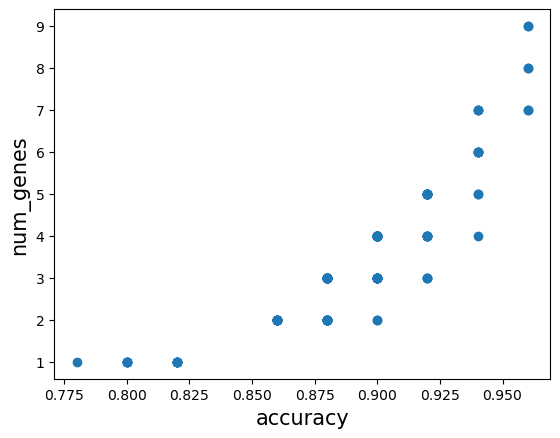

the best one is: accuracy is  0.96 , num of genes is  7
selected genes are:  ['APOE' 'AC012065.7' 'ADRA1D' 'BMI1 ' 'B3GAT2' 'APBB2' 'AURKC']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  14
the best one of generation 1 is: accuracy is  0.9 , num of genes is  14
the best one of generation 2 is: accuracy is  0.9 , num of genes is  11
the best one of generation 3 is: accuracy is  0.96 , num of genes is  14
the best one of generation 4 is: accuracy is  0.96 , num of genes is  14
the best one of generation 5 is: accuracy is  0.96 , num of genes is  14
the best one of generation 6 is: accuracy is  0.96 , num of genes is  14
the best one of generation 7 is: accuracy is  0.96 , num of genes is  14
the best one of generation 8 is: accuracy is  0.96 , num of genes is  14
the best one of generation 9 is: accuracy is  0.96 , num of genes is  14
the best one of generation 10 is: accuracy is  0.96 , num of genes is  14
the best one of generation 11 is: accuracy is  0.96 , num 

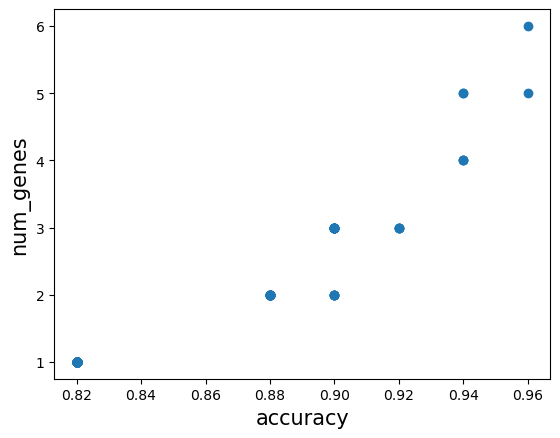

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['BAI2' 'ARHGAP22' 'AMOT' 'ALDH4A1' 'AGO2 ']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  12
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  11
the best one of generation 2 is: accuracy is  0.9 , num of genes is  6
the best one of generation 3 is: accuracy is  0.9 , num of genes is  6
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  13
the best one of generation 5 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 6 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  13
the best one of generation 10 is: accura

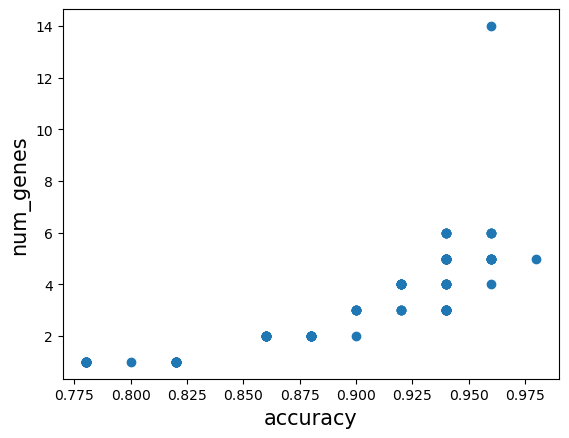

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['AKAP12' 'ANGPT1' 'ADRB1' 'ABL2' 'ATRIP ']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  11
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  6
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  7
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  6
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  6
the 

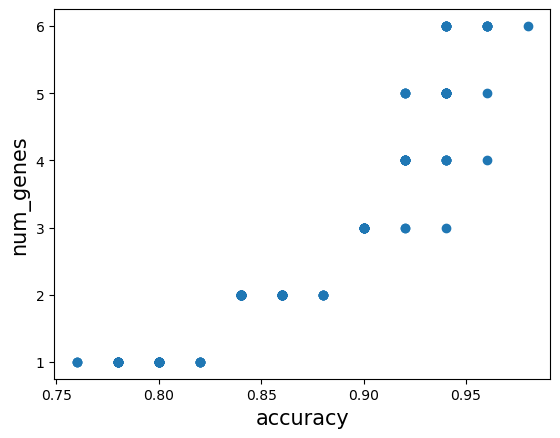

the best one is: accuracy is  0.9800000000000001 , num of genes is  6
selected genes are:  ['ALOX12' 'ARSF' 'AMOT' 'APOC3' 'AZIN1' 'ASIC2']


In [6]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=15,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1

the best one of generation 0 is: accuracy is  0.86 , num of genes is  4
the best one of generation 1 is: accuracy is  0.86 , num of genes is  4
the best one of generation 2 is: accuracy is  0.86 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 11 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 12 is: accuracy is  0.9400000000000001 , 

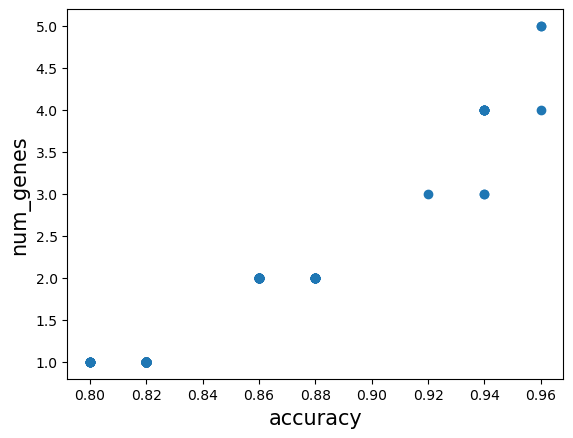

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ABL2' 'BCLAF1' 'ACTG2' 'AFF2']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8400000000000001 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 5 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 6 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 7 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 8 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 9 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 10 

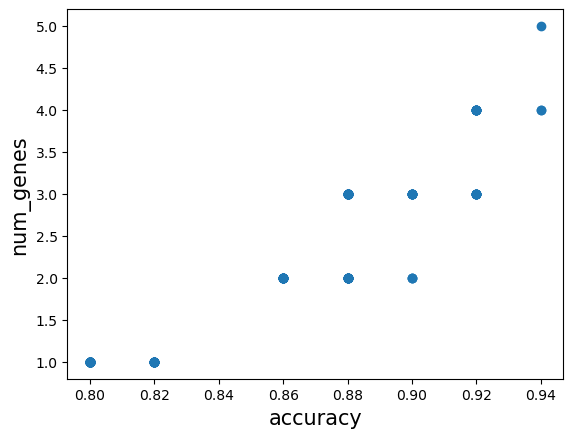

the best one is: accuracy is  0.9400000000000001 , num of genes is  4
selected genes are:  ['ACVR1' 'ADORA2A ' 'AP1S1' 'B3GAT2']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 11 is: accuracy i

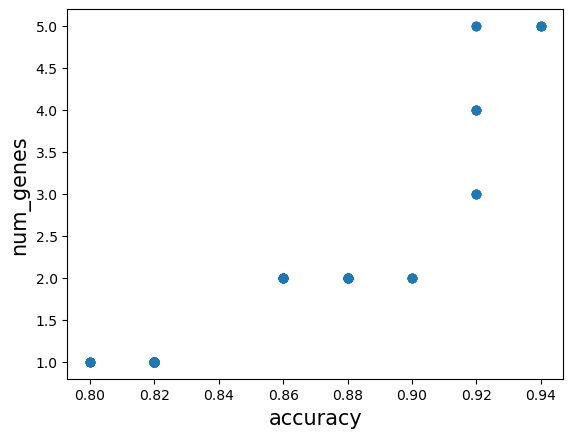

the best one is: accuracy is  0.9400000000000001 , num of genes is  5
selected genes are:  ['ABCC8' 'ARMCX2' 'ARSF' 'ATP6V1E1' 'ARF3']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9200000000000002 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  4
the b

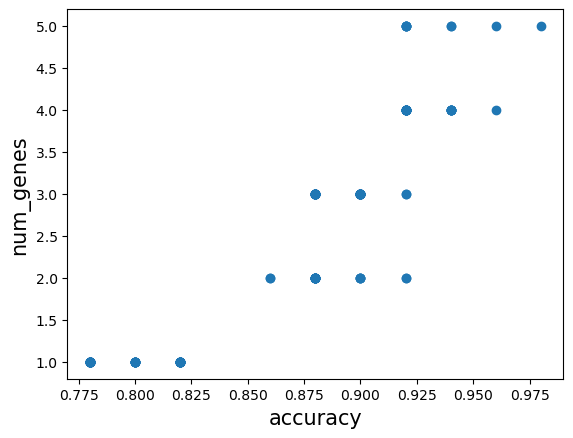

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['ACKR1' 'BMP7' 'ALDOC' 'BMPR1A' 'ASPHD1']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  3
the best one of generation 1 is: accuracy is  0.86 , num of genes is  3
the best one of generation 2 is: accuracy is  0.86 , num of genes is  3
the best one of generation 3 is: accuracy is  0.86 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9 , num of genes is  3
the best one of generation 11 is: accuracy is  0.9 , num of genes is  3
the best

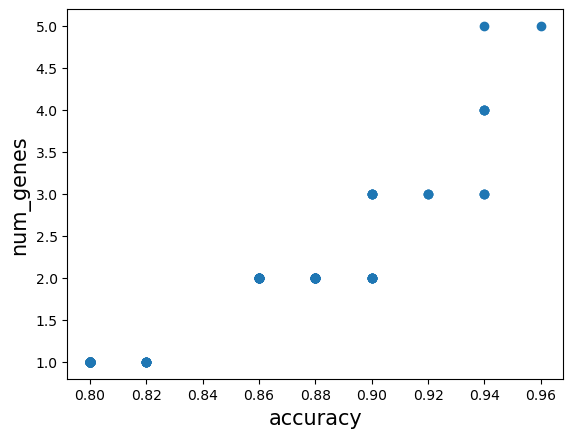

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['BMP2K' 'ALOX12' 'ADAM23' 'ACTC1' 'ARL17A ']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9400000000000

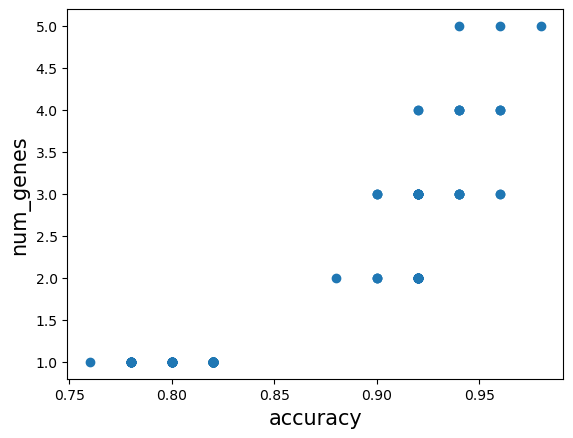

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['ARMCX4' 'ARSF' 'ADRA1D' 'AURKC' 'ARVCF']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9400000000000001 

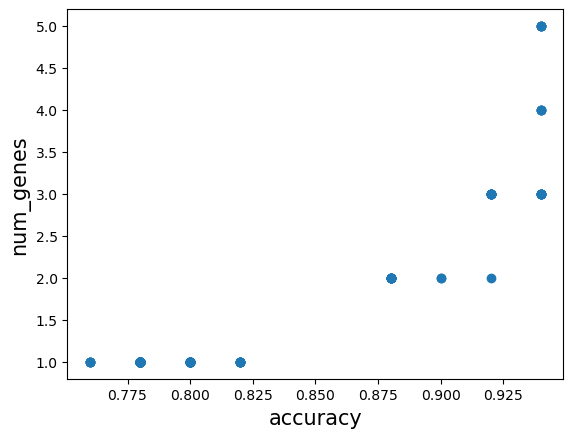

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['ATP2A1' 'ARMCX2' 'AP2A2']
the best one of generation 0 is: accuracy is  0.9 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  5
the best 

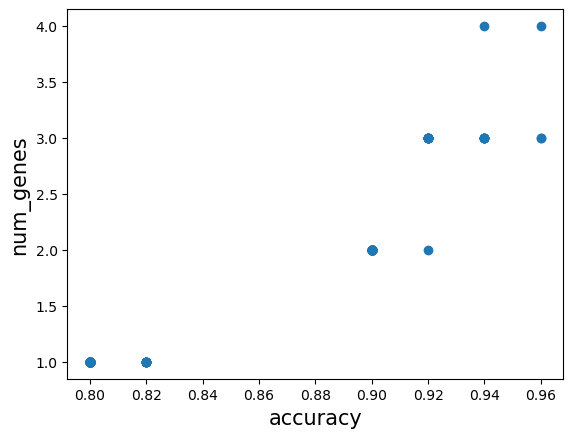

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['ALOX12' 'ACVR1' 'ADRA2A']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8400000000000001 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 11 is: accu

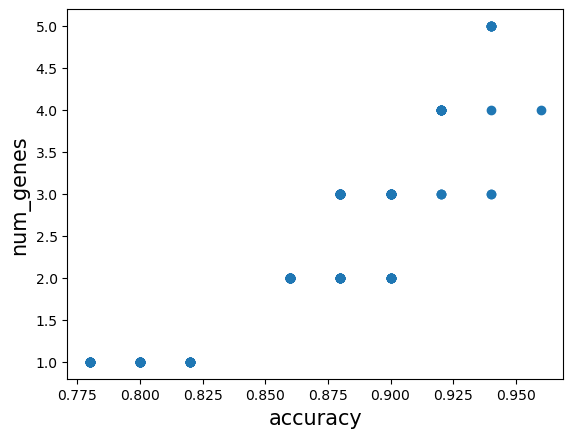

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ARMCX2' 'ATP2A1' 'ADRA2A' 'BAG6']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 3 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 

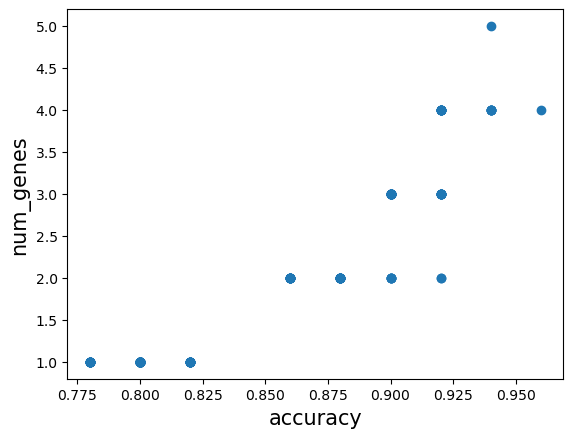

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ARPC5' 'ABL2' 'ATIC' 'BAMBI']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  4
the best one of generation 10 i

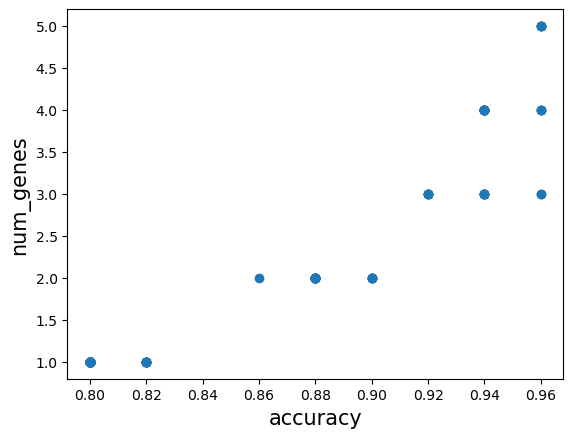

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['ALOX12' 'B2M' 'ARAP2 ']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  2
the best one of generation 1 is: accuracy is  0.86 , num of genes is  2
the best one of generation 2 is: accuracy is  0.86 , num of genes is  2
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 11 is: acc

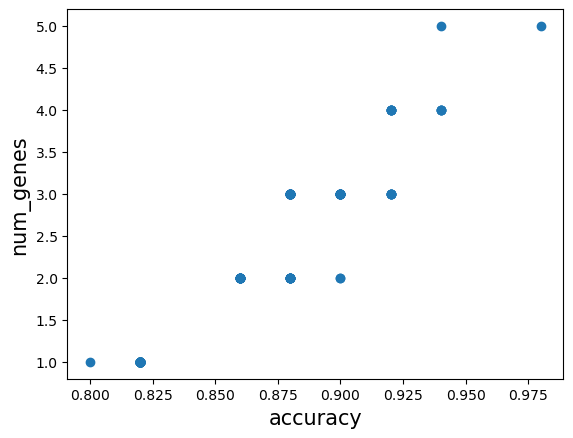

the best one is: accuracy is  0.9800000000000001 , num of genes is  5
selected genes are:  ['AURKC' 'ACVR1' 'AMOT' 'APCS' 'ASB9']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.86 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9400000000000001 , n

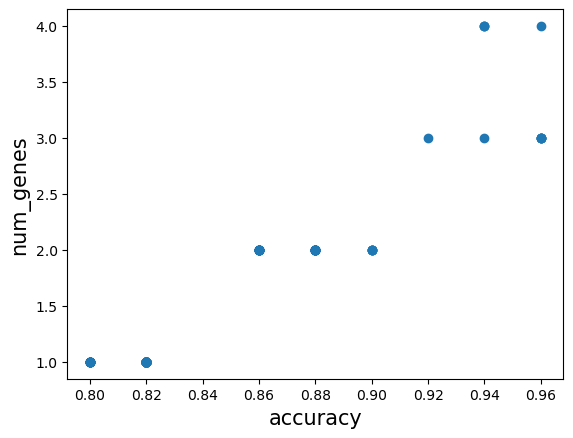

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['ABCC9' 'ATP2A1' 'ALOX12']
the best one of generation 0 is: accuracy is  0.82 , num of genes is  3
the best one of generation 1 is: accuracy is  0.86 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 5 is: accuracy is  0.8800000000000001 , num of genes is  4
the best one of generation 6 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 10 is: accuracy is  0.94000000000000

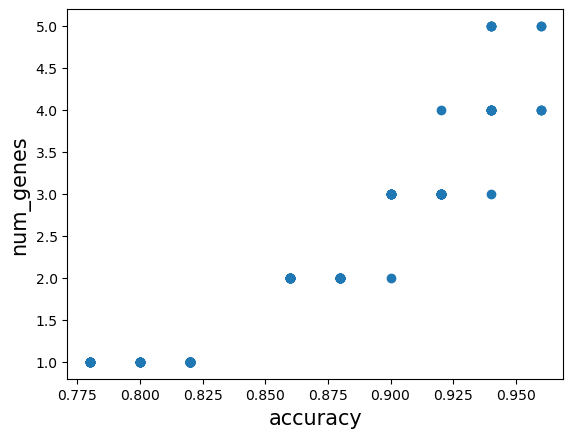

the best one is: accuracy is  0.9600000000000002 , num of genes is  4
selected genes are:  ['ACOX2' 'ADRA2A' 'ARAF' 'BIVM-ERCC5 ']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: accur

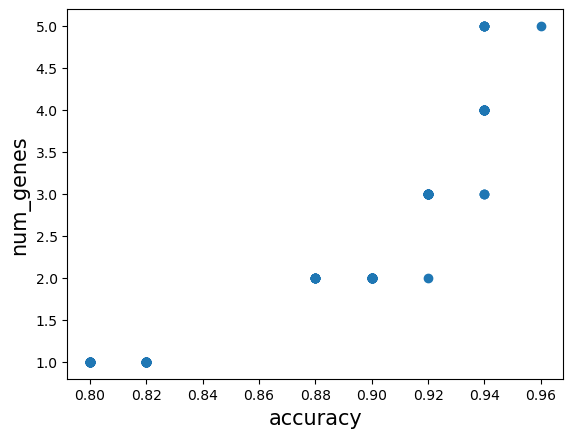

the best one is: accuracy is  0.96 , num of genes is  5
selected genes are:  ['ALOX12' 'AMOT' 'AGPAT2' 'ACVR1' 'AKR1D1']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of gen

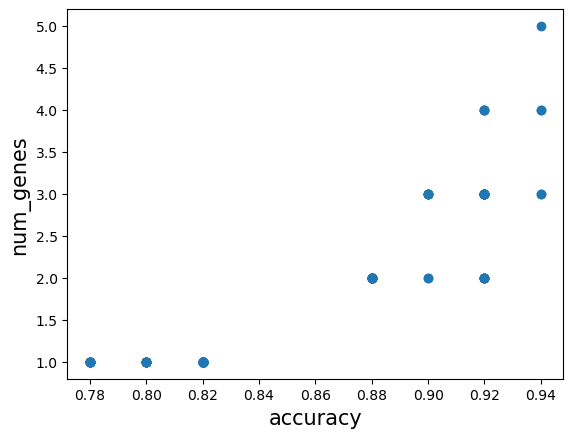

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['APOE' 'BMP5' 'ARL2-SNX15 ']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  3
the best one of generation 2 is: accuracy is  0.9 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9400000000000001 , num of genes is  5
the best one of genera

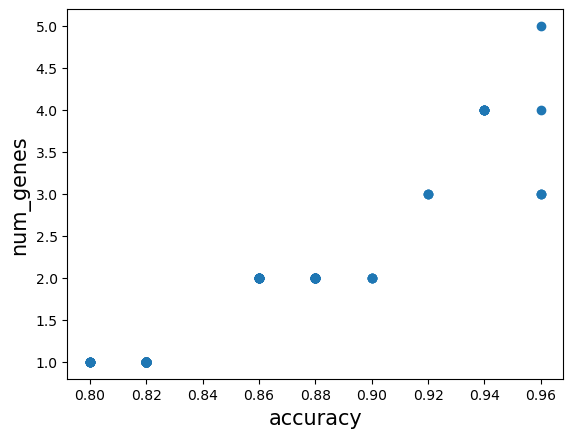

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['ATG12' 'ARSF' 'B3GAT2']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.9 , num of genes is  5
the best one of generation 2 is: accuracy is  0.9 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  5
the best one of generation 4 is: accuracy is  0.9 , num of genes is  5
the best one of generation 5 is: accuracy is  0.9 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 11 is: accuracy is  0.940000

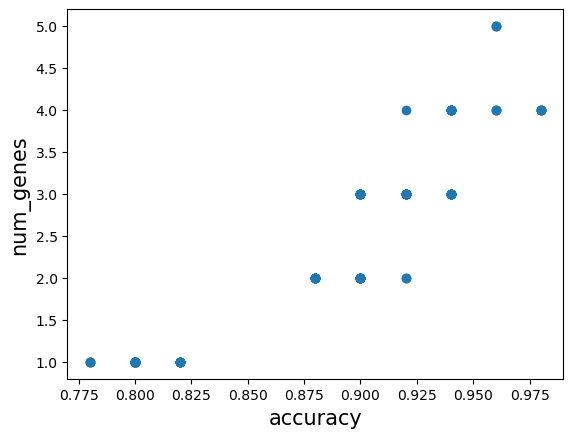

the best one is: accuracy is  0.9800000000000001 , num of genes is  4
selected genes are:  ['ALOX12' 'ADRA2A' 'B2M' 'ABHD2']
the best one of generation 0 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 1 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 2 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 3 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of

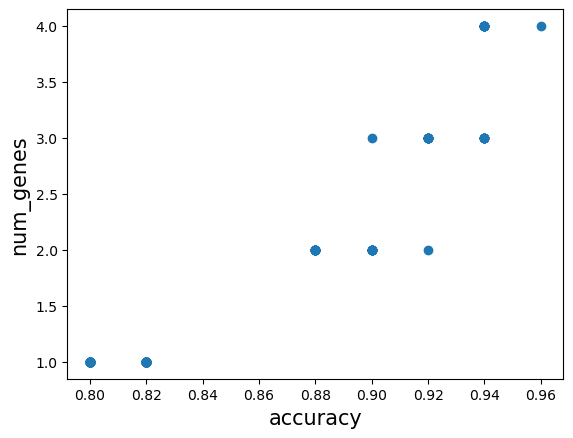

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['ALOX12' 'ATG4A' 'ACTB' 'ACRV1']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 4 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9200000000000002 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9200000000

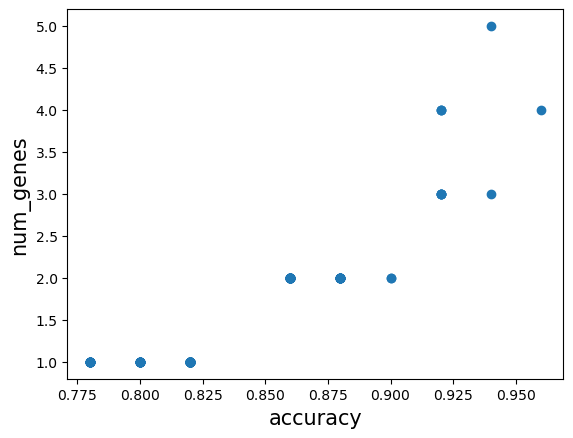

the best one is: accuracy is  0.96 , num of genes is  4
selected genes are:  ['APOE' 'B3GALT2' 'APOC2 ' 'ATF6B']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.9 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  5
the best one of generation 10 is: accuracy is  0.91999999

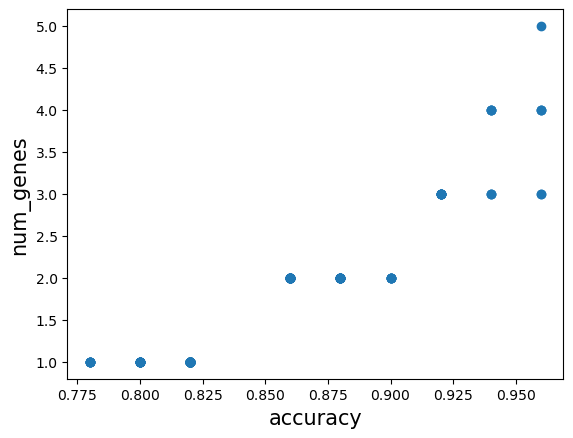

the best one is: accuracy is  0.96 , num of genes is  3
selected genes are:  ['B9D1' 'ADRA2A' 'ABCC1']
the best one of generation 0 is: accuracy is  0.8400000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8399999999999999 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  3
the best one of generation 4 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: acc

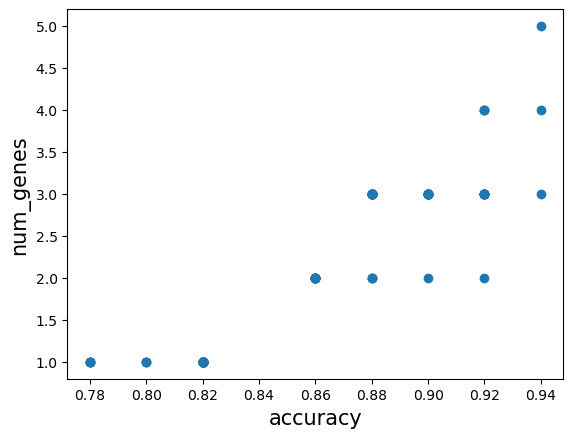

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['ACTN3' 'ADAM18' 'ACTC1']
the best one of generation 0 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 1 is: accuracy is  0.8600000000000001 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8600000000000001 , num of genes is  3
the best one of generation 3 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 4 is: accuracy is  0.9 , num of genes is  3
the best one of generation 5 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: acc

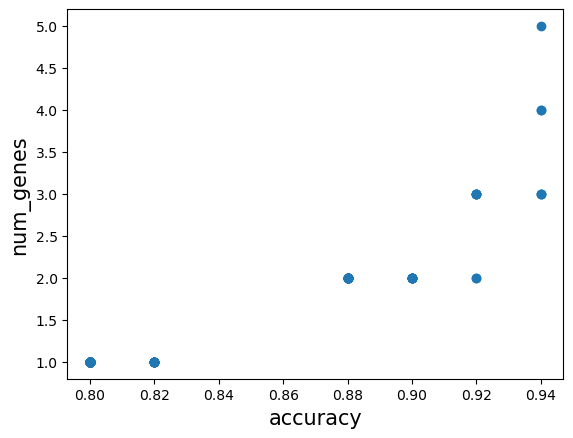

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['BCL2A1' 'ADAM28' 'ABCC10']
the best one of generation 0 is: accuracy is  0.86 , num of genes is  4
the best one of generation 1 is: accuracy is  0.86 , num of genes is  4
the best one of generation 2 is: accuracy is  0.8600000000000001 , num of genes is  2
the best one of generation 3 is: accuracy is  0.8600000000000001 , num of genes is  2
the best one of generation 4 is: accuracy is  0.8600000000000001 , num of genes is  2
the best one of generation 5 is: accuracy is  0.8800000000000001 , num of genes is  2
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  3
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of gen

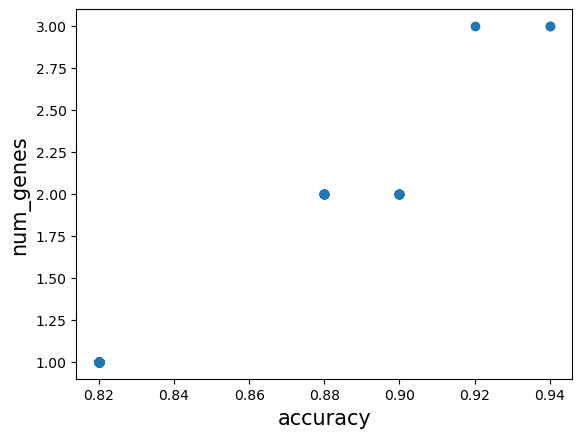

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['APOE' 'AMMECR1' 'AKAP12']
the best one of generation 0 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 1 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 2 is: accuracy is  0.8800000000000001 , num of genes is  5
the best one of generation 3 is: accuracy is  0.9 , num of genes is  4
the best one of generation 4 is: accuracy is  0.9 , num of genes is  4
the best one of generation 5 is: accuracy is  0.9 , num of genes is  4
the best one of generation 6 is: accuracy is  0.9 , num of genes is  4
the best one of generation 7 is: accuracy is  0.9 , num of genes is  4
the best one of generation 8 is: accuracy is  0.9 , num of genes is  4
the best one of generation 9 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generation 10 is: accuracy is  0.9199999999999999 , num of genes is  4
the best one of generati

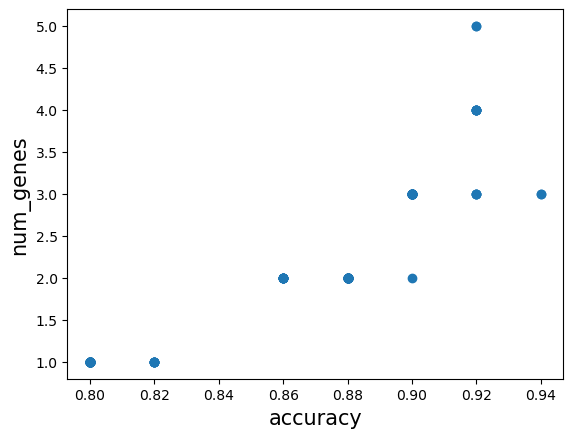

the best one is: accuracy is  0.9400000000000001 , num of genes is  3
selected genes are:  ['AXL' 'ALOX12' 'APBB2']


In [8]:
import warnings
from sklearn.model_selection import StratifiedKFold
warnings.filterwarnings("ignore")
#df = df.values
i = 0
while i < 25:
    nsga2 = NSGA2(all_genes=final_genes, pop_size=160, max_generations=25, max_Ngen=5,features=df, labels=np.array(y))
    solutions = nsga2.execute()
    
    accs = [nsga2.function1(solution) for solution in solutions]
    nums = [len(solution) for solution in solutions]
    plt.xlabel('accuracy', fontsize=15)
    plt.ylabel('num_genes', fontsize=15)
    plt.scatter(accs, nums)
    plt.show()
    f1_values = [nsga2.function1(solution) for solution in solutions]
    f2_values = [nsga2.function2(solution) for solution in solutions]
    scores = 0.95 * np.array(f1_values) + 0.05 * np.array(f2_values)
    print('the best one is: accuracy is ', accs[np.argmax(scores)], ', num of genes is ', nums[np.argmax(scores)])
    print('selected genes are: ', name_genes[solutions[np.argmax(scores)]])
    i = i +1